# Teleoperaattorin tilaajien segmentointi k-means-klusteroinnilla

## Yhteenveto

Teleoperaattori haluaa jakaa jälkikäteislaskutettavan tilaajakuntansa käyttäytymissegmentteihin, jotta se voi kohdentaa asiakaspysyvyystarjouksia ja mitoittaa datapaketit oikein. Tämä muistikirja luo synteettisen tilaajien käyttöaineiston ja ajaa sitten täydellisen k-means-segmentointiketjun Base SAS:ssa: standardoi käyttömuuttujat proseduurilla **PROC STDIZE**, valitsee klustereiden lukumäärän vertaamalla pseudo-F-tunnuslukua eri k:n arvoilla proseduurilla **PROC FASTCLUS**, sovittaa FREQ-painotetun lopullisen mallin, joka pisteyttää jokaisen tilaajan, ja vie opitut keskipisteet niin, että ensi kuun otos voidaan pisteyttää ilman uudelleenklusterointia. Lopputuloksena on uudelleenkäytettävä segmentointi, joka muuntaa raa'an käyttötelemetrian asiakaspysyvyyden toimintasuunnitelmaksi.

## Aineistot

**Synteettinen aineisto: `WORK.SUBSCRIBERS`** (100 jälkikäteislaskutettavaa matkapuhelinliittymän tilaajaa, luotu suoraan koodissa komennolla `call streaminit(20260531)`)

| Muuttuja | Tyyppi | Rooli | Kuvaus |
|----------|--------|-------|--------|
| `cust_id` | Merkkijono | Tunniste | Tilaajan tunniste (esim. `SUB000123`) |
| `tenure_months` | Numero | Selittävä muuttuja | Kuukaudet, jotka liittymä on ollut aktiivinen (1-72) |
| `data_gb` | Numero | Selittävä muuttuja | Keskimääräinen kuukausittainen datankäyttö, Gt |
| `voice_min` | Numero | Selittävä muuttuja | Keskimääräiset kuukausittaiset puheminuutit |
| `intl_min` | Numero | Selittävä muuttuja | Keskimääräiset kuukausittaiset ulkomaanminuutit |
| `support_calls` | Numero | Selittävä muuttuja | Asiakaspalveluyhteydenotot viimeisen 90 päivän aikana |
| `monthly_charge` | Numero | Selittävä muuttuja | Nykyinen kuukausilasku, dollareina |
| `plan_tier` | Merkkijono | Profilointi | Liittymätyyppi: `Perus`, `Plus` tai `Rajaton` |
| `n_lines` | Numero | FREQ-paino | Liittymien lukumäärä tilillä |

Kolme piilevää käyttäytymisprofiilia on upotettu generaattoriin - *kevyt/hintatietoinen*, *paljon dataa käyttävä/suoratoistaja* ja *paljon yhteydenottoja tekevä/riskialtis* - jotta klusteroinnilla on todellista rakennetta löydettävänään. Selittävät muuttujat syötetään k-means-malliin; `plan_tier` jätetään ulkopuolelle jälkikäteistä profilointia varten, ja `n_lines` painottaa jokaista tiliä sen liittymien lukumäärällä. Ulkoisia tiedostoja tai verkkoyhteyttä ei käytetä.

## Käyttäytymissegmentointi viidessä vaiheessa

Matkapuhelinoperaattoreilla on miljoonia jälkikäteislaskutettavia liittymiä, ja yhden koon asiakaspysyvyysstrategia haaskaa katetta asiakkaisiin, jotka pysyisivät joka tapauksessa, samalla kun se jättää huomiotta ne, jotka ovat vaihtamassa operaattoria. **Käyttäytymissegmentointi** muuttaa raa'an käyttötelemetrian muutamaksi toimintakelpoiseksi asiakastyypiksi: *kevyet/hintatietoiset* käyttäjät, jotka ovat hintaherkkiä, *paljon dataa käyttävät suoratoistajat*, jotka ovat hyviä lisämyyntikohteita, ja *paljon yhteydenottoja tekevät/riskialttiit* tilit, jotka tarvitsevat ennakoivaa asiakashoitoa.

Tämä muistikirja rakentaa segmentoinnin proseduurilla `PROC FASTCLUS`, SAS:n k-means-menetelmällä (erillisten klustereiden proseduuri). Etenemme seuraavasti:

1. Luodaan synteettinen mutta realistinen tilaajien käyttöaineisto.
2. Saatetaan selittävät muuttujat yhteiselle asteikolle proseduurilla **PROC STDIZE**.
3. **Valitaan klustereiden lukumäärä** vertaamalla pseudo-F-tunnuslukua eri k:n arvoilla.
4. Sovitetaan FREQ-painotettu lopullinen malli, joka **pisteyttää** jokaisen tilaajan ja profiloi segmentit.
5. **Viedään opitut keskipisteet**, jotta malli voidaan soveltaa uudelleen ensi kuun otokseen.

## Vaihe 1 - Luodaan synteettinen tilaajakunta

Simuloimme 100 jälkikäteislaskutettavaa tilaajaa. Jokainen on poimittu yhdestä kolmesta piilevästä profiilista, joilla on erilaiset käyttösignaturit, joten klusteroinnilla on todellista rakennetta löydettävänään. Kiinnitämme satunnaislukuvirran komennolla `call streaminit` toistettavuuden vuoksi ja rajaamme simuloidut arvot uskottavalle vaihteluvälille funktioilla `max`/`min`/`round`.

Nimellinen `plan_tier` korreloi piilevän profiilin kanssa (suoratoistajat kallistuvat kohti *Rajaton*-liittymää; hintatietoiset käyttäjät kohti *Perus*-liittymää), ja `n_lines` toimii myöhemmin FREQ-painona, jotta monen liittymän perhetilit painottuvat suhteessa niiden kokoon.

In [1]:
TIEDOT subscribers;
    CALL streaminit(20260531);
    PITUUS cust_id $9 plan_tier $9;
    TEE i = 1 ASTI 100;
        cust_id = cats('SUB', KIRJOITA(i, z6.));

        /* Kolme piilevää käyttäytymisprofiilia, epätasainen esiintyvyys */
        u = rand('uniform');
        JOS u < 0.45 NIIN profile = 1;        /* kevyt / hintatietoinen                */
        MUUTEN JOS u < 0.80 NIIN profile = 2;   /* paljon dataa käyttävä / suoratoistaja */
        MUUTEN profile = 3;                    /* paljon yhteydenottoja / riskialtis    */

        JOS profile = 1 NIIN TEE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        LOPPU;
        MUUTEN JOS profile = 2 NIIN TEE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        LOPPU;
        MUUTEN TEE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        LOPPU;

        /* Liittymätyyppi korreloi profiilin kanssa */
        p = rand('uniform');
        JOS profile = 1 NIIN
            plan_tier = ifc(p < 0.70, 'Perus', ifc(p < 0.95, 'Plus', 'Rajaton'));
        MUUTEN JOS profile = 2 NIIN
            plan_tier = ifc(p < 0.65, 'Rajaton', ifc(p < 0.90, 'Plus', 'Perus'));
        MUUTEN
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Rajaton', 'Perus'));

        /* Liittymien lukumäärä tilillä: useimmat ovat yhden liittymän tilejä */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Pyöristetään rahamäärät / käyttöarvot realistiseen tarkkuuteen */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        TULOSTE;
    LOPPU;
    POISTA i u p profile;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=subscribers(obs=10) noobs;
    NIMIKE cust_id="Asiakastunnus" tenure_months="Asiakkuusaika (kk)" data_gb="Datankäyttö (Gt)"
          voice_min="Puheminuutit" intl_min="Ulkomaanminuutit" support_calls="Asiakaspalveluyhteydenotot"
          monthly_charge="Kuukausilasku ($)" plan_tier="Liittymätyyppi" n_lines="Liittymien lkm";
    OTSIKKO "Otos synteettisistä tilaajien käyttötiedoista";
SUORITA;


                                     Otos synteettisistä tilaajien käyttötiedoista                                      

Asiakastunnus   Liittymätyyppi  Asiakkuusaika (kk)    Datankäyttö (Gt)  Puheminuutit  Ulkomaanminuutit  Asiakaspalveluyhteydenotot  Kuukausilasku ($)  Liittymien lkm
SUB000001      Perus                            15                 9.7           114                 5                          11              57.07               2
SUB000002      Perus                            39                 0.6           214                 2                           1              35.88               3
SUB000003      Rajaton                          45                23.9           325                 6                           1             103.94               2
SUB000004      Perus                            41                 1.9           202                 1                           0              61.69               3
SUB000005      Perus                            


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Vaihe 2 - Selittävät muuttujat yhteiselle asteikolle

k-means käyttää euklidista etäisyyttä, joten suurimittakaavainen muuttuja, kuten puheminuutit, hallitsisi pienimittakaavaista muuttujaa, kuten asiakaspalveluyhteydenottoja, jos klusterointi tehtäisiin raakoihin arvoihin. Vakiokeino on standardoida jokainen selittävä muuttuja ensin keskiarvoon 0 ja keskihajontaan 1. **PROC STDIZE** asetuksella `METHOD=STD` tekee juuri tämän ja kirjoittaa z-pisteytetyn kopion tauluun `WORK.SUBS_STD`. Muuttujat `cust_id`, `plan_tier` ja `n_lines` viedään läpi muuttumattomina, jotta ne ovat käytettävissä myöhempää painotusta ja profilointia varten.

In [2]:
PROSEDUURI stdize TIEDOT=subscribers out=subs_std METHOD=std;
    MUUTTUJA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    NIMIKE tenure_months="Asiakkuusaika (kk)" data_gb="Datankäyttö (Gt)" voice_min="Puheminuutit"
          intl_min="Ulkomaanminuutit" support_calls="Asiakaspalveluyhteydenotot" monthly_charge="Kuukausilasku ($)";
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=subs_std mean std maxdec=3;
    MUUTTUJA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    NIMIKE tenure_months="Asiakkuusaika (kk)" data_gb="Datankäyttö (Gt)" voice_min="Puheminuutit"
          intl_min="Ulkomaanminuutit" support_calls="Asiakaspalveluyhteydenotot" monthly_charge="Kuukausilasku ($)";
    OTSIKKO "Standardoidut muuttujat: keskiarvo ~ 0, keskihajonta ~ 1";
SUORITA;


                                     Otos synteettisistä tilaajien käyttötiedoista                                      

                                Standardoidut muuttujat: keskiarvo ~ 0, keskihajonta ~ 1                                

                                                  The MEANS Procedure

 Variable        Label                                Mean     Std Dev
 ---------------------------------------------------------------------
 tenure_months   Asiakkuusaika (kk)                  0.000       1.000
 data_gb         Datankäyttö (Gt)                   -0.000       1.000
 voice_min       Puheminuutit                       -0.000       1.000
 intl_min        Ulkomaanminuutit                    0.000       1.000
 support_calls   Asiakaspalveluyhteydenotot         -0.000       1.000
 monthly_charge  Kuukausilasku ($)                   0.000       1.000
 ---------------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Vaihe 3 - Kuinka monta segmenttiä? Verrataan pseudo-F-tunnuslukua eri k:n arvoilla

Sen sijaan, että arvaisimme klustereiden lukumäärän, sovitamme FASTCLUS-proseduurin jokaisella ehdokas-k:lla ja luemme sen raportoimat mallin sopivuustunnusluvut. **Pseudo-F-tunnusluku** (klustereiden välisen ja sisäisen varianssin suhde) ja **kokonais-R-neliö** palkitsevat molemmat erottelusta; hyvä k on sellainen, jossa pseudo-F on korkea ja seuraavan klusterin lisääminen tuottaa vähenevää hyötyä. Lyhyt makrosilmukka ajaa arvot k = 2, 3, 4 asetuksilla `MAXITER=50` ja `CONVERGE=0` (iteroidaan vakauteen asti). Vertaa `Pseudo F Statistic`- ja `Overall R-Squared`-rivejä kolmessa alla olevassa listauksessa: upotetussa rakenteessa on kolme piilevää profiilia, ja k = 3 antaa vahvimman ja tasapainoisimman ratkaisun.

In [3]:
%macro pick_k;
    %TEE k = 2 %ASTI 4;
        PROSEDUURI FASTCLUS TIEDOT=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            MUUTTUJA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            NIMIKE tenure_months="Asiakkuusaika (kk)" data_gb="Datankäyttö (Gt)" voice_min="Puheminuutit"
                  intl_min="Ulkomaanminuutit" support_calls="Asiakaspalveluyhteydenotot" monthly_charge="Kuukausilasku ($)";
            OTSIKKO "Ehdolla oleva klustereiden lukumäärä: k = &k";
        SUORITA;
    %LOPPU;
%mend pick_k;
%pick_k;


                                Standardoidut muuttujat: keskiarvo ~ 0, keskihajonta ~ 1                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Vaihe 4 - Sovitetaan lopullinen segmentointi ja pisteytetään jokainen tilaaja

Kun k = 3 on valittu, sovitamme tuotantomallin. Tämä ajo on täysin idiomaattinen operatiiviselle segmentoinnille:

- `FREQ`-lause painottaa jokaista tiliä muuttujalla `n_lines`, joten neljän liittymän perhetili vaikuttaa keskipisteiden laskennassa neljä kertaa niin paljon kuin yhden liittymän tili.
- `OUT=SCORED` kirjoittaa jokaisen tilaajan sen `CLUSTER`-arvon ja `DISTANCE`-etäisyyden kanssa kyseisen klusterin keskipisteeseen; `ID`-lause vie muuttujan `cust_id` mukana pisteytettyyn tauluun.
- `MEAN=SEG_MEANS` tallentaa klusterikohtaiset keskipisteet (standardoidulla asteikolla).
- `OUTSEED=SEG_SEEDS` tallentaa lopulliset keskipisteet siemenmuodossa, jonka FASTCLUS osaa lukea takaisin - tämä on viety malli, jota sovellamme uudelleen vaiheessa 6.

Mallin sopivuustunnusluvut on jo selvitetty vaiheen 3 vertailussa, joten lisäämme tähän `SHORT`-asetuksen pitääksemme listauksen keskittyneenä pisteytystä ohjaaviin klusterikokoihin ja keskipisteisiin.

In [4]:
PROSEDUURI FASTCLUS TIEDOT=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    MUUTTUJA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    FREKVENSSIT n_lines;
    id cust_id;
    NIMIKE tenure_months="Asiakkuusaika (kk)" data_gb="Datankäyttö (Gt)" voice_min="Puheminuutit"
          intl_min="Ulkomaanminuutit" support_calls="Asiakaspalveluyhteydenotot" monthly_charge="Kuukausilasku ($)";
    OTSIKKO "Lopullinen segmentointi: k = 3, painotettu liittymien lukumäärällä (FREQ)";
SUORITA;

PROSEDUURI TULOSTA TIEDOT=seg_means noobs;
    NIMIKE CLUSTER="Klusteri" tenure_months="Asiakkuusaika (kk)" data_gb="Datankäyttö (Gt)" voice_min="Puheminuutit"
          intl_min="Ulkomaanminuutit" support_calls="Asiakaspalveluyhteydenotot" monthly_charge="Kuukausilasku ($)"
          _freq_="Liittymien lkm";
    OTSIKKO "Segmenttien keskipisteet (standardoitu asteikko)";
SUORITA;


                                Standardoidut muuttujat: keskiarvo ~ 0, keskihajonta ~ 1                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Vaihe 5 - Profiloidaan segmentit liiketoimintayksiköissä

Pisteytetty taulu sisältää jokaisen tilaajan `CLUSTER`-tunnuksen, mutta standardoidulla asteikolla keskipisteitä on vaikea tulkita. Jotta klusterinumerot muuttuisivat liiketoimintapersooniksi, liitämme tunnuksen takaisin alkuperäiseen `subscribers`-tauluun ja profiloimme todellisissa yksiköissä - gigatavuina, minuutteina ja dollareina. PROC MEANS tiivistää selittävät muuttujat segmentin mukaan, ja PROC FREQ ristiintaulukoi ulkopuolelle jätetyn `plan_tier`-muuttujan segmentin mukaan näyttääkseen kunkin persoonan liittymäjakauman.

                   Segmenttiprofiilit: keskimääräinen käyttö klusterin mukaan (alkuperäiset yksiköt)                    

                                                  The MEANS Procedure

                                 Analysis Variable : tenure_months Asiakkuusaika (kk)

                                          N
                            Klusteri    Obs      Mean      Std Dev      Minimum      Maximum
                            ----------------------------------------------------------------
                            1            51      33.2         14.7          1.0         61.0
                            2            31      40.5         14.0         17.0         67.0
                            3            18      12.7          7.1          1.0         30.0
                            ----------------------------------------------------------------

                                    Analysis Variable : data_gb Datankäyttö (Gt)

                                   


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


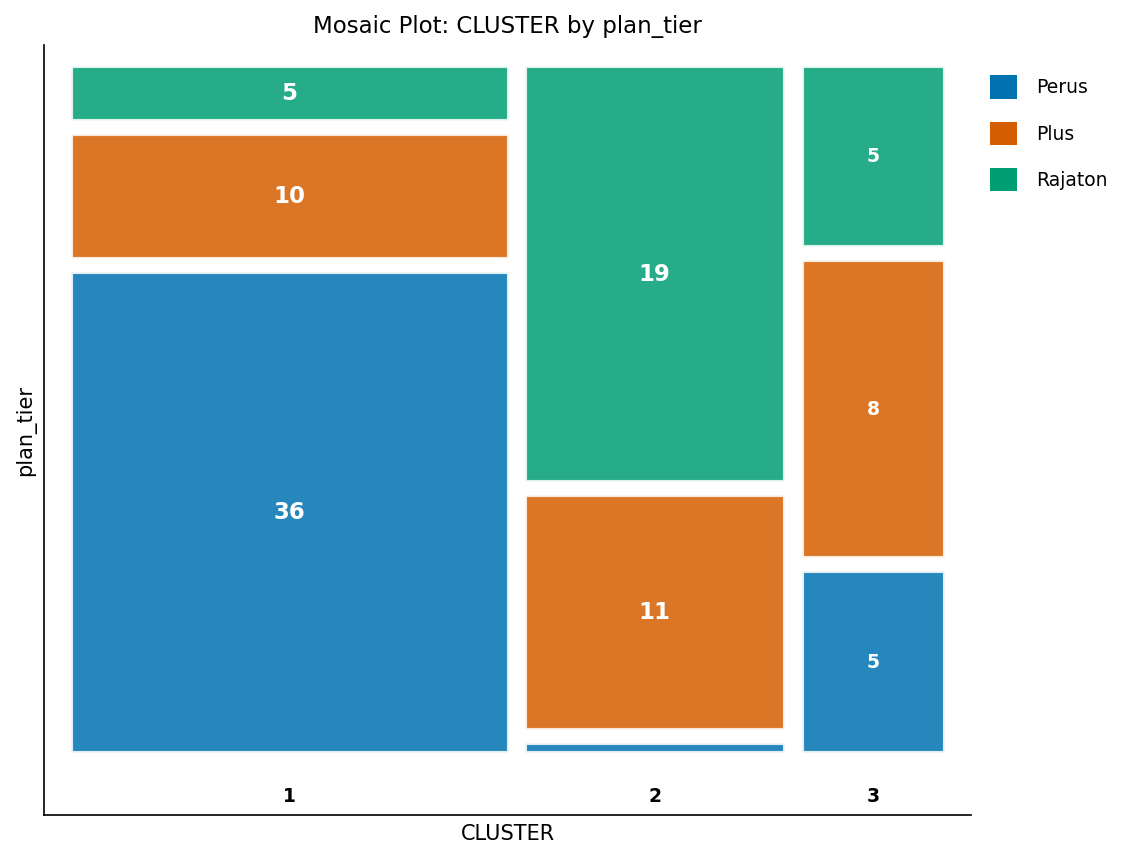

In [5]:
PROSEDUURI LAJITTELE TIEDOT=scored out=scored_keys(SÄILYTÄ=cust_id CLUSTER);
    MUKAAN cust_id;
SUORITA;

PROSEDUURI LAJITTELE TIEDOT=subscribers out=subs_sorted;
    MUKAAN cust_id;
SUORITA;

TIEDOT profile;
    YHDISTÄ subs_sorted(SISÄLLÄ=a) scored_keys(SISÄLLÄ=b);
    MUKAAN cust_id;
    JOS a AND b;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=profile mean std MIN MAX maxdec=1;
    LUOKKA CLUSTER;
    MUUTTUJA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    NIMIKE CLUSTER="Klusteri" tenure_months="Asiakkuusaika (kk)" data_gb="Datankäyttö (Gt)" voice_min="Puheminuutit"
          intl_min="Ulkomaanminuutit" support_calls="Asiakaspalveluyhteydenotot" monthly_charge="Kuukausilasku ($)";
    OTSIKKO "Segmenttiprofiilit: keskimääräinen käyttö klusterin mukaan (alkuperäiset yksiköt)";
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    NIMIKE CLUSTER="Klusteri" plan_tier="Liittymätyyppi";
    OTSIKKO "Liittymätyyppien jakauma kussakin segmentissä";
SUORITA;


## Vaihe 6 - Sovelletaan mallia uudelleen ensi kuun otokseen

Segmentointi on hyödyllinen vain, jos se voidaan soveltaa uudelleen ilman koko ajon uudelleenajamista. Vaiheessa 4 tauluun `SEG_SEEDS` tallennetut keskipisteet ovat siirrettävä malli: kun ne syötetään takaisin asetuksella `SEED=SEG_SEEDS` ja `MAXITER=0`, FASTCLUS *kohdistaa* jokaisen havainnon lähimpään tallennettuun keskipisteeseen siirtämättä keskipisteitä - puhdasta pisteytystä, ei uudelleensovitusta. Tässä pisteytämme saman standardoidun otoksen uudelleen varmistaaksemme, että viety malli toistaa alkuperäiset kohdistukset; tuotannossa `DATA=`-asetus osoittaisi sen sijaan ensi kuun standardoituun otokseen.

                                     Liittymätyyppien jakauma kussakin segmentissä                                      


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


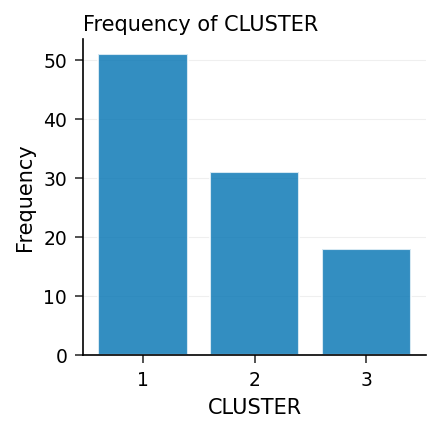

In [6]:
PROSEDUURI FASTCLUS TIEDOT=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    MUUTTUJA tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    NIMIKE tenure_months="Asiakkuusaika (kk)" data_gb="Datankäyttö (Gt)" voice_min="Puheminuutit"
          intl_min="Ulkomaanminuutit" support_calls="Asiakaspalveluyhteydenotot" monthly_charge="Kuukausilasku ($)";
    OTSIKKO "Uuden otoksen pisteytys viedyillä keskipisteillä";
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=rescored;
    TABLES CLUSTER / nocum;
    NIMIKE CLUSTER="Klusteri";
    OTSIKKO "Uudelleenpisteytetyt tilaajat viedyllä mallilla";
SUORITA;


## Tulosten tulkinta

FASTCLUS löysi kolme aineistoon upotettua käyttäytymissegmenttiä, ja profilointitaulut kääntävät ne asiakaspysyvyyden toimintasuunnitelmaksi. Lue segmenttinumerot yllä olevasta *Segmenttiprofiilit*-taulusta - klustereiden tunnukset ovat mielivaltaisia, joten tunnista kukin persoona sen käyttösignatuurin perusteella:

- **Kevyet/hintatietoiset käyttäjät** - vähän dataa, vaatimattomat laskut, pidempi asiakkuusaika, hyvin vähän asiakaspalveluyhteydenottoja, enimmäkseen *Perus*-liittymässä. Nämä asiakkaat ovat vakaita ja hintaherkkiä; oikea toimenpide on *suojata katetta*, ei alennuksia. Oikein mitoitettu liittymäsuositus estää laskutusyllätykset ilman lahjoja.
- **Paljon dataa käyttävät suoratoistajat** - paljon dataa, paljon puhe- ja ulkomaanminuutteja, premium-laskut, enimmäkseen *Rajaton*-liittymässä. He ovat uskollisia ja arvokkaita: pelisuunnitelma on *lisämyynti ja laitepäivitykset* sekä ennakoiva verkon laatua koskeva viestintä, jotta kilpailijan tarjous ei houkuttele heitä pois.
- **Paljon yhteydenottoja tekevät/riskialttiit** - lyhyt asiakkuusaika, kohonnut asiakaspalveluyhteydenottojen määrä, keskitason kulutus. Tiheät hoitokontaktit yhdessä lyhyen asiakkuusajan kanssa ovat klassisia poistuman ennusmerkkejä. Tämä on segmentti, joka ansaitsee *ennakoivan asiakaspysyvyystarjouksen* ja palvelun palautusseurannan.

Menettelyvalinnat, jotka tekivät tästä luotettavan: **PROC STDIZE** esti suurimittakaavaisia puheminuutteja hukuttamasta asiakaspalvelusignaalia; pseudo-F-vertailu perusteli klustereiden lukumäärän arvaamisen sijaan; `FREQ`-paino sai monen liittymän perhetilit painottumaan suhteessa niiden kokoon; ja `OUTSEED=`/`SEED=`-kierros vei keskipisteet niin, että markkinointitiimi voi segmentoida jokaisen kuukausittaisen otoksen uudelleen yhdellä `MAXITER=0`-FASTCLUS-kutsulla - ilman uudelleenklusterointia.